In [5]:
import time

#from visualization.point_clouds import vis_2pcs_aligned_vs_misaligned, vis_pc
from utils.optimize_parameters import optimize_with_ax

In [ ]:

t1 = time.perf_counter()
# optimize_with_ax(samples_training=25, samples_test=25)
optimize_with_ax(samples_training=5, samples_test=5)

print(f"It took {round(time.perf_counter()-t1)} seconds to run basic run")
#model, X_train, X_test, y_train, y_test = main.differential_entropy_classification()

In [1]:
import nuscenes as ns

# Init Nusc object
data_folder = 'data/nuscenes/'
version = 'v1.0-mini'
nusc = ns.nuscenes.NuScenes(version=version, dataroot=data_folder, verbose=False)

In [ ]:
# Load data
from utils.data_handling import read_nuscenes_data, split_data
PC_scenes = read_nuscenes_data(nusc, n_scenes=100, n_samples=100, downsample_factor=2,
                               T_close_thresh=1.5)
PC_scenes_training, PC_scenes_test = split_data(PC_scenes, scenes_training=60)
del PC_scenes

In [ ]:
from classifiers.differential_entropy import differential_entropy_dataset
from classifiers.regression import perform_logistic_regression

scale_factor = 5
params_diff_entropy = {
    "rmin": 0.2*scale_factor,
    "rmax": 1*scale_factor,
    "log_epsilon": -18.0,
    "alpha": 1.33*scale_factor,
    "E_reject": 0.20
}


X_train, y_train = differential_entropy_dataset(PC_scenes_training, params_diff_entropy)
X_test, y_test = differential_entropy_dataset(PC_scenes_test, params_diff_entropy)
model, accuracy_test = perform_logistic_regression(X_train, X_test, y_train, y_test, verbose=True)
print(f"Accuracy: {accuracy_test} with parameters\n {params_diff_entropy}")
print("Finito!")

In [2]:
from utils.data_handling import run_differential_entropy_on_dataset
from utils.parameters import Params
from classifiers.regression import perform_logistic_regression

###### Define data to collect
n_scenes = 10
n_samples_per_scene = 1
train_ratio = 0.60 # Percent of data set aside for training, rest is for testing

####### Set parameters
scale_factor = 5
params_diff_entropy = {
    "rmin": 0.2*scale_factor,
    "rmax": 1*scale_factor,
    "log_epsilon": -18.0,
    "alpha": 1.33*scale_factor,
    "E_reject": 0.20
}
T_close_thresh = 1.5
downsample_factor = 8
verbose = False
##

params = Params(nusc=nusc, n_scenes=n_scenes, n_samples_per_scene=n_samples_per_scene, train_ratio=train_ratio,
                downsample_factor=downsample_factor, T_close_thresh=T_close_thresh,
                params_diff_entropy=params_diff_entropy)

X_train, y_train, X_test, y_test = run_differential_entropy_on_dataset(params)

#### Test performance
model, accuracy_test = perform_logistic_regression(X_train, X_test, y_train, y_test, verbose=True)
print(f"Accuracy: {accuracy_test} with parameters\n {params_diff_entropy}")
print("Finito!")


AttributeError: 'Params' object has no attribute 'n_training_scenes'

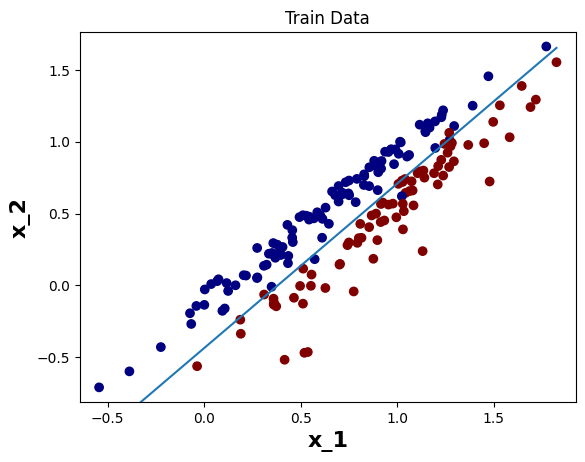

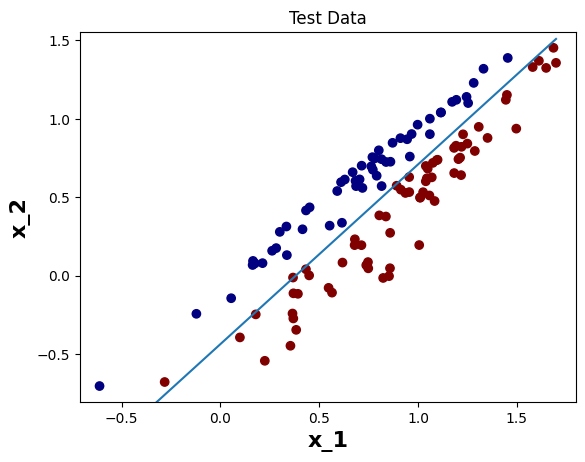

In [6]:
from visualization.classifications import model_plot

# Train Data
model_plot(model,X_train,y_train,'Train Data')
# Test Dataset Result9s
model_plot(model,X_test,y_test,'Test Data')

In [ ]:
import ipywidgets as widgets
import matplotlib.pyplot as plt

def plot_point_cloud_interactive(pc):
    def plot(elev=30, azim=30):
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')

        xs = pc[:, 0]
        ys = pc[:, 1]
        zs = pc[:, 2]

        ax.scatter(xs, ys, zs, marker='o')

        ax.set_xlabel('X Label')
        ax.set_ylabel('Y Label')
        ax.set_zlabel('Z Label')

        ax.view_init(elev, azim)
        plt.show()

    widgets.interact(plot, elev=(-90, 90, 5), azim=(-180, 180, 5))

PC_scenes = read_nuscenes_data()
PC_scene = PC_scenes[0]
PC_pair = PC_scene[0]

#plot_point_cloud_interactive(PC_pair.PC0.pc.cpu().numpy())


import plotly.graph_objs as go

def plot_point_cloud_plotly(pc):
    x, y, z = pc[:, 0], pc[:, 1], pc[:, 2]

    trace = go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(
            size=2,
            opacity=0.8
        )
    )

    layout = go.Layout(
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        )
    )

    fig = go.Figure(data=[trace], layout=layout)
    fig.show()

plot_point_cloud_plotly(PC_pair.PC0.pc.cpu().numpy())
